# KnowYourLoan — Final ANN & Explainability

**Team:** Slytherin  
**Project:** KnowYourLoan  
**Tagline:** Predict. Explain. Simulate.

This notebook contains the finalized machine-learning pipeline for loan approval prediction.

### Final scope
- Dataset: 4,269-row loan approval dataset
- Model: Deep Learning ANN
- Target: Loan Approved / Rejected
- Explainability: SHAP
- Train / Validation / Test split: 70% / 15% / 15%
- No SMOTE in the final pipeline
- No What-If analysis
- `loan_id` is excluded from model training


## 1. Load Dataset

In [13]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Load dataset
df = pd.read_csv("loan_approval_dataset.csv")

# Clean column names
df.columns = df.columns.str.strip()

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())


Dataset shape: (4269, 13)
Columns: ['loan_id', 'no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']


## 2. Data Cleaning & Audit

In [14]:
# Remove leading/trailing spaces from categorical text values
df["education"] = df["education"].astype(str).str.strip()
df["self_employed"] = df["self_employed"].astype(str).str.strip()
df["loan_status"] = df["loan_status"].astype(str).str.strip()

print("Education values:", df["education"].unique())
print("Self-employed values:", df["self_employed"].unique())
print("Loan status values:", df["loan_status"].unique())


Education values: ['Graduate' 'Not Graduate']
Self-employed values: ['No' 'Yes']
Loan status values: ['Approved' 'Rejected']


In [15]:
print("===== DATASET INFO =====")
df.info()

print("\n===== MISSING VALUES =====")
print(df.isnull().sum())

print("\n===== DUPLICATE ROWS =====")
print("Duplicates:", df.duplicated().sum())

print("\n===== TARGET DISTRIBUTION =====")
print(df["loan_status"].value_counts())

print("\n===== TARGET PERCENTAGE =====")
print((df["loan_status"].value_counts(normalize=True) * 100).round(2))


===== DATASET INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB

====

In [16]:
print("===== NUMERICAL FEATURE STATISTICS =====")
numeric_cols = df.select_dtypes(include=np.number).columns
print(df[numeric_cols].describe().T)


===== NUMERICAL FEATURE STATISTICS =====
                           count          mean           std       min  \
loan_id                   4269.0  2.135000e+03  1.232498e+03       1.0   
no_of_dependents          4269.0  2.498712e+00  1.695910e+00       0.0   
income_annum              4269.0  5.059124e+06  2.806840e+06  200000.0   
loan_amount               4269.0  1.513345e+07  9.043363e+06  300000.0   
loan_term                 4269.0  1.090045e+01  5.709187e+00       2.0   
cibil_score               4269.0  5.999361e+02  1.724304e+02     300.0   
residential_assets_value  4269.0  7.472617e+06  6.503637e+06 -100000.0   
commercial_assets_value   4269.0  4.973155e+06  4.388966e+06       0.0   
luxury_assets_value       4269.0  1.512631e+07  9.103754e+06  300000.0   
bank_asset_value          4269.0  4.976692e+06  3.250185e+06       0.0   

                                25%         50%         75%         max  
loan_id                      1068.0      2135.0      3202.0      4269.

In [17]:
print("===== UNIQUE VALUES =====")
for col in df.columns:
    print(f"\n{col}")
    print("Unique:", df[col].nunique())
    print("Sample values:", df[col].unique()[:10])


===== UNIQUE VALUES =====

loan_id
Unique: 4269
Sample values: [ 1  2  3  4  5  6  7  8  9 10]

no_of_dependents
Unique: 6
Sample values: [2 0 3 5 4 1]

education
Unique: 2
Sample values: ['Graduate' 'Not Graduate']

self_employed
Unique: 2
Sample values: ['No' 'Yes']

income_annum
Unique: 98
Sample values: [9600000 4100000 9100000 8200000 9800000 4800000 8700000 5700000  800000
 1100000]

loan_amount
Unique: 378
Sample values: [29900000 12200000 29700000 30700000 24200000 13500000 33000000 15000000
  2200000  4300000]

loan_term
Unique: 10
Sample values: [12  8 20 10  4  2 18 16 14  6]

cibil_score
Unique: 601
Sample values: [778 417 506 467 382 319 678 782 388 547]

residential_assets_value
Unique: 278
Sample values: [ 2400000  2700000  7100000 18200000 12400000  6800000 22500000 13200000
  1300000  3200000]

commercial_assets_value
Unique: 188
Sample values: [17600000  2200000  4500000  3300000  8200000  8300000 14800000  5700000
   800000  1400000]

luxury_assets_value
Unique: 379


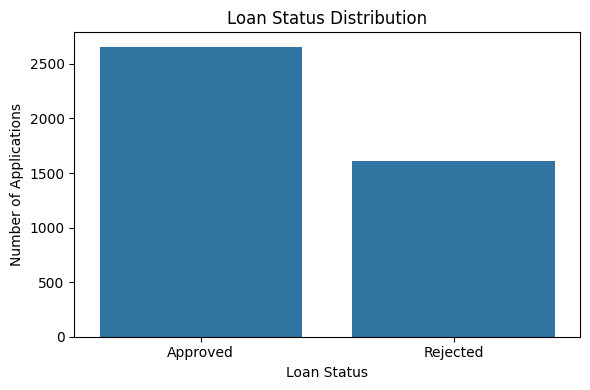

In [18]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="loan_status")
plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applications")
plt.tight_layout()
plt.show()


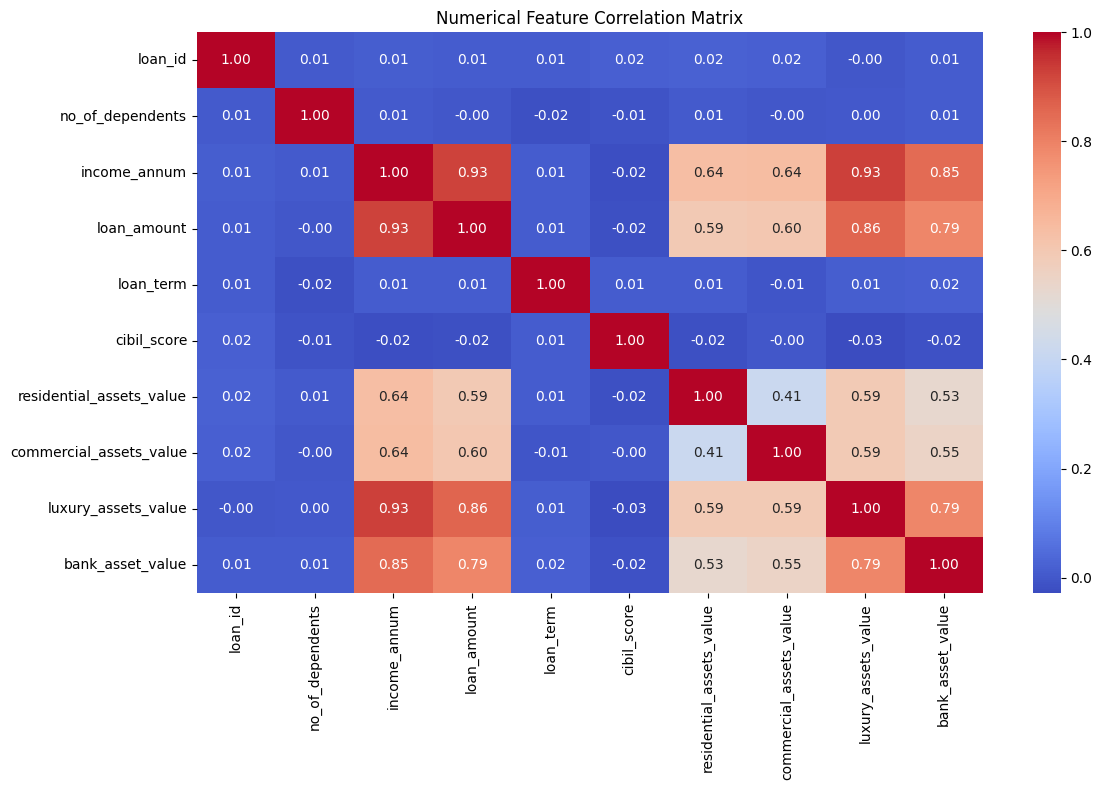

In [19]:
plt.figure(figsize=(12, 8))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Numerical Feature Correlation Matrix")
plt.tight_layout()
plt.show()


## 3. Final Feature Setup

In [20]:
# Exclude the unique identifier and target from model features
X = df.drop(columns=["loan_id", "loan_status"])

# Encode target
y = df["loan_status"].map({
    "Approved": 1,
    "Rejected": 0
})

print("Features:", X.columns.tolist())
print("X shape:", X.shape)
print("\nTarget distribution:")
print(y.value_counts())
print("\nTarget NaN values:", y.isna().sum())


Features: ['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']
X shape: (4269, 11)

Target distribution:
loan_status
1    2656
0    1613
Name: count, dtype: int64

Target NaN values: 0


In [21]:
# 70% training, 15% validation, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)


Training: (2988, 11)
Validation: (640, 11)
Testing: (641, 11)


In [22]:
categorical_features = [
    "education",
    "self_employed"
]

numerical_features = [
    col for col in X.columns
    if col not in categorical_features
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

# Fit only on training data to prevent preprocessing leakage
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Processed training:", X_train_processed.shape)
print("Processed validation:", X_val_processed.shape)
print("Processed testing:", X_test_processed.shape)


Processed training: (2988, 13)
Processed validation: (640, 13)
Processed testing: (641, 13)


## 4. Final ANN Model

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

input_size = X_train_processed.shape[1]

model = Sequential([
    Input(shape=(input_size,)),
    Dense(64, activation="relu"),
    Dropout(0.20),
    Dense(32, activation="relu"),
    Dropout(0.15),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

history = model.fit(
    X_train_processed,
    y_train,
    validation_data=(X_val_processed, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7118 - auc: 0.8295 - loss: 0.5300 - precision: 0.6965 - recall: 0.9516 - val_accuracy: 0.8828 - val_auc: 0.9520 - val_loss: 0.3097 - val_precision: 0.8892 - val_recall: 0.9271 - learning_rate: 0.0010
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8899 - auc: 0.9501 - loss: 0.2771 - precision: 0.9162 - recall: 0.9059 - val_accuracy: 0.9266 - val_auc: 0.9729 - val_loss: 0.1945 - val_precision: 0.9606 - val_recall: 0.9196 - learning_rate: 0.0010
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9083 - auc: 0.9639 - loss: 0.2329 - precision: 0.9371 - recall: 0.9139 - val_accuracy: 0.9422 - val_auc: 0.9793 - val_loss: 0.1692 - val_precision: 0.9616 - val_recall: 0.9447 - learning_rate: 0.0010
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9140 - auc: 0.9676 - loss: 0.2194 - precision: 0.9391 - recall: 0.9215 - val_accuracy: 0.9391 - val_auc: 0.9817 - val_loss: 0.1603 - val_pre

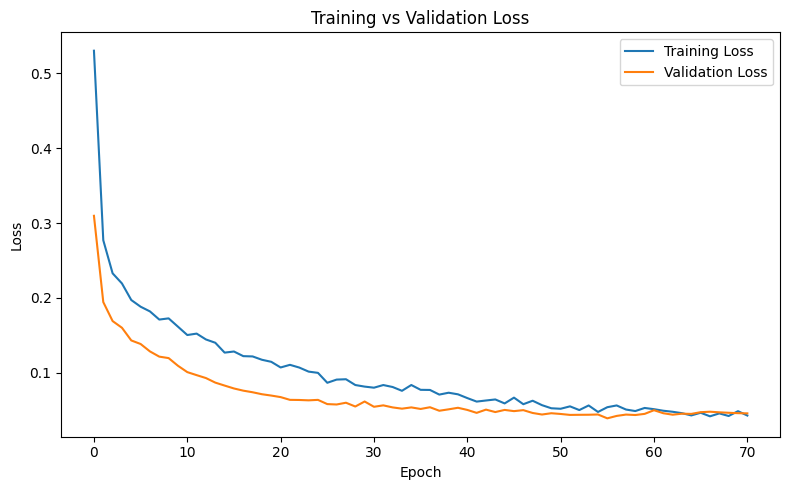

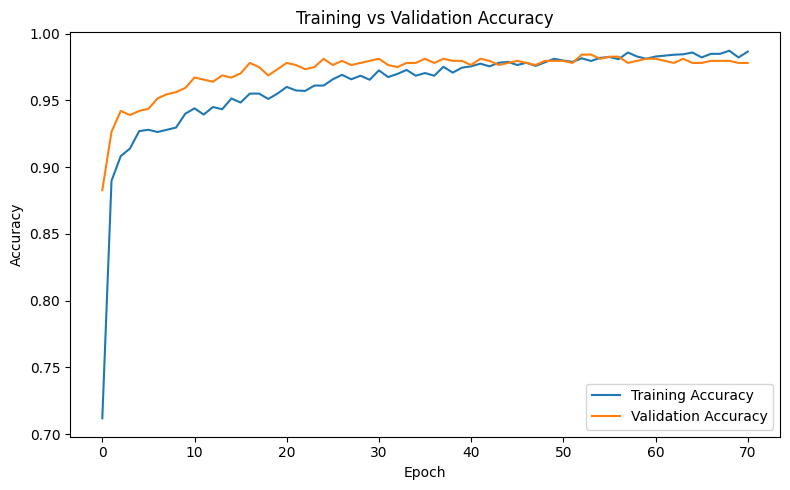

In [25]:
# Training history
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()


## 5. Final Test Evaluation

In [26]:
# Predict probabilities and classes on the untouched test set
y_prob = model.predict(
    X_test_processed,
    verbose=0
).ravel()

y_pred = (y_prob >= 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("===== FINAL ANN TEST PERFORMANCE =====")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\n===== CLASSIFICATION REPORT =====")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Rejected", "Approved"]
    )
)

print("\n===== CONFUSION MATRIX =====")
print(confusion_matrix(y_test, y_pred))


===== FINAL ANN TEST PERFORMANCE =====
Accuracy : 0.9735
Precision: 0.9659
Recall   : 0.9925
F1 Score : 0.9790
ROC-AUC  : 0.9966

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

    Rejected       0.99      0.94      0.96       242
    Approved       0.97      0.99      0.98       399

    accuracy                           0.97       641
   macro avg       0.98      0.97      0.97       641
weighted avg       0.97      0.97      0.97       641


===== CONFUSION MATRIX =====
[[228  14]
 [  3 396]]


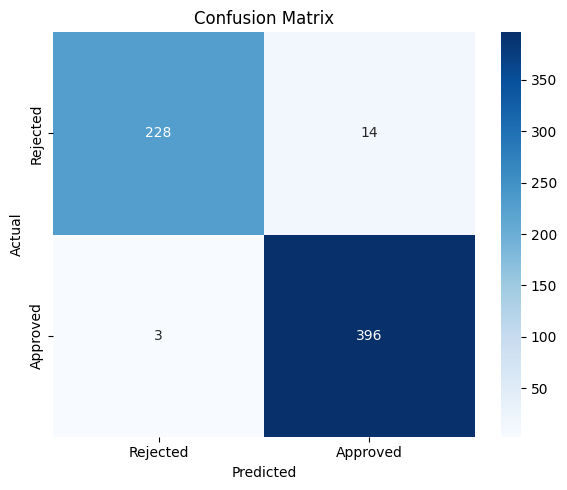

In [27]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Rejected", "Approved"],
    yticklabels=["Rejected", "Approved"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


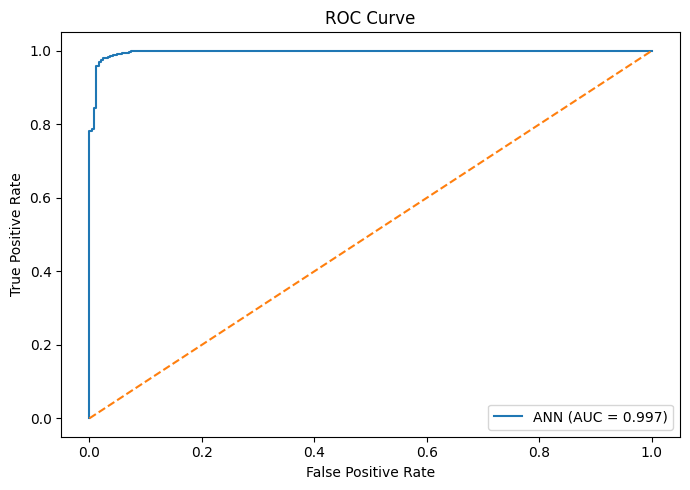

In [28]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(
    fpr,
    tpr,
    label=f"ANN (AUC = {roc_auc:.3f})"
)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()


In [29]:
print("===== OVERFITTING SANITY CHECK =====")
print(f"Best training accuracy   : {max(history.history['accuracy']):.4f}")
print(f"Best validation accuracy : {max(history.history['val_accuracy']):.4f}")
print(f"Best validation loss     : {min(history.history['val_loss']):.4f}")
print(f"Test accuracy            : {accuracy:.4f}")


===== OVERFITTING SANITY CHECK =====
Best training accuracy   : 0.9873
Best validation accuracy : 0.9844
Best validation loss     : 0.0394
Test accuracy            : 0.9735


## 6. Diagnostic Checks

In [30]:
# Check for duplicate feature combinations.
# loan_id is intentionally excluded because it is only an identifier.
feature_columns = [
    "no_of_dependents",
    "education",
    "self_employed",
    "income_annum",
    "loan_amount",
    "loan_term",
    "cibil_score",
    "residential_assets_value",
    "commercial_assets_value",
    "luxury_assets_value",
    "bank_asset_value"
]

duplicate_features = df.duplicated(
    subset=feature_columns,
    keep=False
)

print(
    "Rows involved in duplicate feature combinations:",
    duplicate_features.sum()
)

if duplicate_features.sum() == 0:
    print("No duplicate feature combinations found.")
else:
    print(df.loc[
        duplicate_features,
        feature_columns + ["loan_status"]
    ].sort_values(feature_columns).head(20))


Rows involved in duplicate feature combinations: 0
No duplicate feature combinations found.


In [31]:
# Logistic Regression diagnostic baseline
from sklearn.linear_model import LogisticRegression

baseline = LogisticRegression(
    max_iter=2000,
    random_state=42
)

baseline.fit(X_train_processed, y_train)

baseline_prob = baseline.predict_proba(X_test_processed)[:, 1]
baseline_pred = (baseline_prob >= 0.5).astype(int)

print("===== LOGISTIC REGRESSION DIAGNOSTIC =====")
print(f"Accuracy: {accuracy_score(y_test, baseline_pred):.4f}")
print(f"ROC-AUC : {roc_auc_score(y_test, baseline_prob):.4f}")


===== LOGISTIC REGRESSION DIAGNOSTIC =====
Accuracy: 0.9267
ROC-AUC : 0.9719


In [32]:
# Decision Tree diagnostic baseline
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

tree.fit(X_train_processed, y_train)

tree_prob = tree.predict_proba(X_test_processed)[:, 1]
tree_pred = (tree_prob >= 0.5).astype(int)

print("===== DECISION TREE DIAGNOSTIC =====")
print(f"Accuracy: {accuracy_score(y_test, tree_pred):.4f}")
print(f"ROC-AUC : {roc_auc_score(y_test, tree_prob):.4f}")


===== DECISION TREE DIAGNOSTIC =====
Accuracy: 0.9626
ROC-AUC : 0.9900


In [33]:
# CIBIL / target relationship audit
check_df = df.copy()
check_df["approved"] = (
    check_df["loan_status"] == "Approved"
).astype(int)

check_df["cibil_group"] = pd.cut(
    check_df["cibil_score"],
    bins=[0, 500, 600, 650, 700, 750, 800, 900],
    labels=[
        "0-500",
        "501-600",
        "601-650",
        "651-700",
        "701-750",
        "751-800",
        "801-900"
    ]
)

cibil_analysis = (
    check_df
    .groupby("cibil_group", observed=False)
    .agg(
        applications=("loan_status", "count"),
        approved=("approved", "sum"),
        approval_rate=("approved", "mean")
    )
)

cibil_analysis["approval_rate"] *= 100

print(cibil_analysis)


             applications  approved  approval_rate
cibil_group                                       
0-500                1406       150      10.668563
501-600               738       392      53.116531
601-650               333       333     100.000000
651-700               367       363      98.910082
701-750               372       371      99.731183
751-800               362       359      99.171271
801-900               691       688      99.565847


In [34]:
# Correlation with the target for audit purposes only.
analysis_df = df.copy()

analysis_df["education_encoded"] = (
    analysis_df["education"]
    .map({"Graduate": 1, "Not Graduate": 0})
)

analysis_df["self_employed_encoded"] = (
    analysis_df["self_employed"]
    .map({"Yes": 1, "No": 0})
)

analysis_df["target"] = (
    analysis_df["loan_status"]
    .map({"Approved": 1, "Rejected": 0})
)

correlation_features = [
    "no_of_dependents",
    "income_annum",
    "loan_amount",
    "loan_term",
    "cibil_score",
    "residential_assets_value",
    "commercial_assets_value",
    "luxury_assets_value",
    "bank_asset_value",
    "education_encoded",
    "self_employed_encoded",
    "target"
]

target_corr = (
    analysis_df[correlation_features]
    .corr()["target"]
    .drop("target")
    .sort_values(key=abs, ascending=False)
)

print("===== CORRELATION WITH LOAN STATUS =====")
print(target_corr)


===== CORRELATION WITH LOAN STATUS =====
cibil_score                 0.770518
loan_term                  -0.113036
no_of_dependents           -0.018114
loan_amount                 0.016150
luxury_assets_value        -0.015465
income_annum               -0.015189
residential_assets_value   -0.014367
commercial_assets_value     0.008246
bank_asset_value           -0.006778
education_encoded           0.004918
self_employed_encoded       0.000345
Name: target, dtype: float64


## 7. Save Final Artifacts & Verify Reload

In [35]:
model.save("loan_ann.keras")
joblib.dump(preprocessor, "loan_preprocessor.pkl")

feature_config = {
    "features": feature_columns,
    "categorical_features": categorical_features,
    "numerical_features": numerical_features,
    "target": {
        "0": "Rejected",
        "1": "Approved"
    }
}

with open("feature_config.json", "w") as f:
    json.dump(feature_config, f, indent=4)

print("Saved:")
print("- loan_ann.keras")
print("- loan_preprocessor.pkl")
print("- feature_config.json")


Saved:
- loan_ann.keras
- loan_preprocessor.pkl
- feature_config.json


In [36]:
from tensorflow.keras.models import load_model

loaded_model = load_model("loan_ann.keras")
loaded_preprocessor = joblib.load("loan_preprocessor.pkl")

original_predictions = model.predict(
    X_test_processed,
    verbose=0
).ravel()

loaded_predictions = loaded_model.predict(
    loaded_preprocessor.transform(X_test),
    verbose=0
).ravel()

difference = np.max(
    np.abs(original_predictions - loaded_predictions)
)

print("Model and preprocessor loaded successfully.")
print("Maximum prediction difference:", difference)


Model and preprocessor loaded successfully.
Maximum prediction difference: 0.0


## 8. SHAP Explainability

In [37]:
# Install once in Colab if SHAP is not already available.
!pip install -q shap


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflowjs 3.18.0 requires packaging~=20.9, but you have packaging 26.3 which is incompatible.


In [38]:
import shap

print("SHAP version:", shap.__version__)

# Small training background sample for the explainer
background_size = min(100, len(X_train_processed))
background_indices = np.random.choice(
    len(X_train_processed),
    background_size,
    replace=False
)

X_background = X_train_processed[background_indices]

explainer = shap.GradientExplainer(
    loaded_model,
    X_background
)

print("SHAP explainer created successfully.")


SHAP version: 0.52.0
SHAP explainer created successfully.


In [39]:
# Explain up to 200 test applications for global importance
explain_size = min(200, len(X_test_processed))
X_explain = X_test_processed[:explain_size]

shap_values = explainer.shap_values(X_explain)

if isinstance(shap_values, list):
    shap_values = shap_values[0]

shap_values = np.array(shap_values)

if shap_values.ndim == 3:
    shap_values = shap_values[:, :, 0]

feature_names = preprocessor.get_feature_names_out()

print("SHAP values shape:", shap_values.shape)
print("Number of features:", len(feature_names))


/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=['Tensor(shape=(200, 13))']
  warnings.warn(msg)
/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=['Tensor(shape=(50, 13))']
  warnings.warn(msg)


SHAP values shape: (200, 13)
Number of features: 13


In [40]:
mean_abs_shap = np.mean(
    np.abs(shap_values),
    axis=0
)

shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean Absolute SHAP": mean_abs_shap
}).sort_values(
    "Mean Absolute SHAP",
    ascending=False
)

print(shap_importance)


                          Feature  Mean Absolute SHAP
4                num__cibil_score            0.468887
3                  num__loan_term            0.037546
2                num__loan_amount            0.030419
9         cat__education_Graduate            0.025662
12         cat__self_employed_Yes            0.024453
10    cat__education_Not Graduate            0.024329
1               num__income_annum            0.023516
11          cat__self_employed_No            0.022904
7        num__luxury_assets_value            0.008748
8           num__bank_asset_value            0.007198
5   num__residential_assets_value            0.006594
6    num__commercial_assets_value            0.005413
0           num__no_of_dependents            0.004663


<Figure size 1000x600 with 0 Axes>

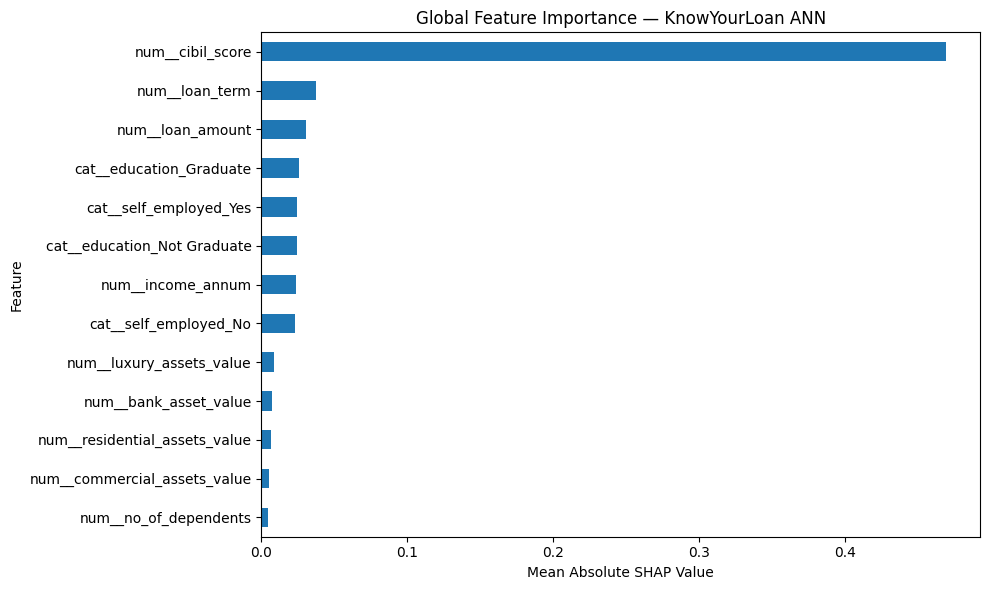

In [41]:
plt.figure(figsize=(10, 6))

shap_importance.head(15).sort_values(
    "Mean Absolute SHAP"
).plot(
    x="Feature",
    y="Mean Absolute SHAP",
    kind="barh",
    legend=False,
    figsize=(10, 6)
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Global Feature Importance — KnowYourLoan ANN")
plt.tight_layout()
plt.show()


## 9. Reusable Prediction + Explanation Function

In [42]:
def clean_feature_name(name):
    name = name.replace("num__", "")
    name = name.replace("cat__", "")

    feature_map = {
        "cibil_score": "CIBIL Score",
        "loan_term": "Loan Term",
        "loan_amount": "Loan Amount",
        "income_annum": "Annual Income",
        "no_of_dependents": "Number of Dependents",
        "residential_assets_value": "Residential Assets",
        "commercial_assets_value": "Commercial Assets",
        "luxury_assets_value": "Luxury Assets",
        "bank_asset_value": "Bank Assets",
        "education_Graduate": "Education: Graduate",
        "education_Not Graduate": "Education: Not Graduate",
        "self_employed_Yes": "Employment: Self-Employed",
        "self_employed_No": "Employment: Not Self-Employed"
    }

    return feature_map.get(name, name)


def explain_loan_application(application_data, top_n=5):
    """Predict and explain one loan application.

    Returns:
        prediction: Approved or Rejected
        probability: model approval probability
        explanation: top SHAP-influencing factors
    """

    application_df = pd.DataFrame([application_data])

    application_df["education"] = (
        application_df["education"].astype(str).str.strip()
    )
    application_df["self_employed"] = (
        application_df["self_employed"].astype(str).str.strip()
    )

    processed_input = loaded_preprocessor.transform(application_df)

    probability = float(
        loaded_model.predict(
            processed_input,
            verbose=0
        )[0][0]
    )

    prediction = (
        "Approved"
        if probability >= 0.5
        else "Rejected"
    )

    input_shap = explainer.shap_values(processed_input)

    if isinstance(input_shap, list):
        input_shap = input_shap[0]

    input_shap = np.array(input_shap)

    if input_shap.ndim == 3:
        input_shap = input_shap[:, :, 0]

    input_shap = input_shap[0]

    explanation = pd.DataFrame({
        "Feature": feature_names,
        "SHAP Value": input_shap,
        "Absolute SHAP": np.abs(input_shap)
    })

    explanation["Readable Feature"] = (
        explanation["Feature"].apply(clean_feature_name)
    )

    explanation["Direction"] = np.where(
        explanation["SHAP Value"] > 0,
        "Supports Approval",
        "Supports Rejection"
    )

    explanation = explanation.sort_values(
        "Absolute SHAP",
        ascending=False
    ).head(top_n)

    return {
        "prediction": prediction,
        "probability": probability,
        "explanation": explanation[
            [
                "Readable Feature",
                "SHAP Value",
                "Direction"
            ]
        ].to_dict(orient="records")
    }


## 10. Example Prediction + Explanation

In [43]:
test_application = {
    "no_of_dependents": 1,
    "education": "Graduate",
    "self_employed": "No",
    "income_annum": 4100000,
    "loan_amount": 10000000,
    "loan_term": 6,
    "cibil_score": 891,
    "residential_assets_value": 4900000,
    "commercial_assets_value": 300000,
    "luxury_assets_value": 12600000,
    "bank_asset_value": 3600000
}

result = explain_loan_application(
    test_application,
    top_n=5
)

print("Prediction:", result["prediction"])
print(f"Probability: {result['probability']:.4f}")

print("\nTop factors:")
for factor in result["explanation"]:
    print(
        f"{factor['Readable Feature']}: "
        f"{factor['Direction']} "
        f"({factor['SHAP Value']:.6f})"
    )


Prediction: Approved
Probability: 0.9967

Top factors:
CIBIL Score: Supports Approval (0.603313)
Loan Amount: Supports Rejection (-0.013464)
Education: Not Graduate: Supports Rejection (-0.012705)
Education: Graduate: Supports Approval (0.012237)
Annual Income: Supports Approval (0.005159)


/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=['Tensor(shape=(1, 13))']
  warnings.warn(msg)


## Final Status

The finalized ML pipeline is complete:

- Final ANN trained and evaluated
- Test metrics recorded
- Overfitting sanity check completed
- Model, preprocessor, and feature configuration saved
- Reload verification completed
- Global SHAP analysis completed
- Individual SHAP explanation completed
- Reusable prediction + explanation function completed

**Deployment and the `Under Review` safety/admin workflow belong in the backend layer, not as a third ANN class.**


In [44]:
import numpy as np

# Save a small background dataset for SHAP
X_background = X_train[:100]

np.save("shap_background.npy", X_background)

print("Saved:", "shap_background.npy")
print("Shape:", X_background.shape)

Saved: shap_background.npy
Shape: (100, 11)


In [45]:
import tensorflow as tf
import sklearn
import shap
import numpy as np
import pandas as pd
import joblib

print("Python:", __import__("sys").version)
print("TensorFlow:", tf.__version__)
print("Scikit-learn:", sklearn.__version__)
print("SHAP:", shap.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Joblib:", joblib.__version__)

Python: 3.13.16 (main, Oct  1 2026, 15:40:24) [GCC 13.3.0]
TensorFlow: 2.21.0
Scikit-learn: 1.6.1
SHAP: 0.52.0
NumPy: 2.1.3
Pandas: 2.2.3
Joblib: 1.6.0


In [46]:
# Save SHAP background AFTER preprocessing
X_train_transformed = preprocessor.transform(X_train)

X_background = X_train_transformed[:100]

np.save("shap_background.npy", X_background)

print("Saved:", "shap_background.npy")
print("Shape:", X_background.shape)

Saved: shap_background.npy
Shape: (100, 13)


In [47]:
!pip install -q tensorflowjs

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scikit-image 0.25.2 requires packaging>=21, but you have packaging 20.9 which is incompatible.
jupyter-server 2.20.0 requires packaging>=22.0, but you have packaging 20.9 which is incompatible.
langchain-core 1.6.6 requires packaging>=23.2.0, but you have packaging 20.9 which is incompatible.
db-dtypes 1.7.1 requires packaging>=24.2.0, but you have packaging 20.9 which is incompatible.
shap 0.52.0 requires packaging>20.9, but you have packaging 20.9 which is incompatible.
sphinx 8.2.3 requires packaging>=23.0, but you have packaging 20.9 which is incompatible.
google-cloud-bigquery 3.45.2 requires packaging>=24.2.0, but you have packaging 20.9 which is incompatible.
astropy 7.2.2 requires packaging>=22.0.0, but you have packaging 20.9 which is incompatible.
pysal 25.7 requires packaging>=22, but you have packaging

In [48]:
!pip install -q --upgrade "packaging>=24.2"

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflowjs 3.18.0 requires packaging~=20.9, but you have packaging 26.3 which is incompatible.


In [49]:
# import tensorflowjs as tfjs

# tfjs.converters.save_keras_model(
#     model,
#     "know_your_loan_tfjs"
# )

# print("TensorFlow.js model created successfully!")

In [50]:
import packaging
print(packaging.__version__)

20.9


In [51]:
import numpy as np

# Compatibility patch for tensorflowjs converter
np.object = object
np.bool = bool

print("NumPy compatibility patch applied")

NumPy compatibility patch applied


In [52]:
import tensorflowjs as tfjs

print("TensorFlow.js converter imported successfully")

AttributeError: module 'tensorflow.compat.v1' has no attribute 'estimator'

In [53]:
from tensorflow.keras.models import load_model

model = load_model("loan_ann.keras")

print("Model loaded successfully!")
model.summary()

Model loaded successfully!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,565 (41.27 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,044 (27.52 KB)

In [54]:
weights = model.get_weights()

print("Number of weight arrays:", len(weights))

for i, w in enumerate(weights):
    print(f"{i}: shape={w.shape}")

Number of weight arrays: 8
0: shape=(13, 64)
1: shape=(64,)
2: shape=(64, 32)
3: shape=(32,)
4: shape=(32, 16)
5: shape=(16,)
6: shape=(16, 1)
7: shape=(1,)


In [55]:
import json
import numpy as np

weights = model.get_weights()

model_data = {
    "architecture": {
        "input_size": 13,
        "layers": [
            {"units": 64, "activation": "relu"},
            {"units": 32, "activation": "relu"},
            {"units": 16, "activation": "relu"},
            {"units": 1, "activation": "sigmoid"}
        ]
    },
    "weights": [
        w.tolist() for w in weights
    ]
}

with open("know_your_loan_model.json", "w") as f:
    json.dump(model_data, f)

print("Model exported successfully!")
print("File: know_your_loan_model.json")
print("Number of weight arrays:", len(weights))

Model exported successfully!
File: know_your_loan_model.json
Number of weight arrays: 8


In [56]:
import joblib

preprocessor = joblib.load("loan_preprocessor.pkl")

print("Preprocessor loaded successfully!")
print(preprocessor)

Preprocessor loaded successfully!
ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['no_of_dependents', 'income_annum',
                                  'loan_amount', 'loan_term', 'cibil_score',
                                  'residential_assets_value',
                                  'commercial_assets_value',
                                  'luxury_assets_value', 'bank_asset_value']),
                                ('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['education', 'self_employed'])])


In [57]:
import json
import numpy as np

# Get fitted preprocessing components
scaler = preprocessor.named_transformers_["num"]
encoder = preprocessor.named_transformers_["cat"]

preprocessing_data = {
    "numerical_features": numerical_features,
    "categorical_features": categorical_features,

    "scaler": {
        "mean": scaler.mean_.tolist(),
        "scale": scaler.scale_.tolist()
    },

    "encoder": {
        "categories": [
            category.tolist()
            for category in encoder.categories_
        ]
    },

    "feature_names": preprocessor.get_feature_names_out().tolist()
}

with open("know_your_loan_preprocessing.json", "w") as f:
    json.dump(preprocessing_data, f, indent=2)

print("Preprocessing exported successfully!")
print()
print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)
print("Scaler values:", len(scaler.mean_))
print("Encoder categories:", encoder.categories_)
print("Final processed features:", len(preprocessor.get_feature_names_out()))
print("File: know_your_loan_preprocessing.json")

Preprocessing exported successfully!

Numerical features: ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']
Categorical features: ['education', 'self_employed']
Scaler values: 9
Encoder categories: [array(['Graduate', 'Not Graduate'], dtype=object), array(['No', 'Yes'], dtype=object)]
Final processed features: 13
File: know_your_loan_preprocessing.json


In [58]:
import json
import numpy as np

# --------------------------------------------------
# Load exported model + preprocessing JSON
# --------------------------------------------------

with open("know_your_loan_model.json", "r") as f:
    exported_model = json.load(f)

with open("know_your_loan_preprocessing.json", "r") as f:
    exported_preprocessing = json.load(f)

# --------------------------------------------------
# Convert exported weights back to NumPy arrays
# --------------------------------------------------

exported_weights = [
    np.array(w, dtype=np.float32)
    for w in exported_model["weights"]
]

# --------------------------------------------------
# JavaScript-equivalent preprocessing
# --------------------------------------------------

def preprocess_for_browser(application):
    numerical_features = exported_preprocessing["numerical_features"]
    categorical_features = exported_preprocessing["categorical_features"]

    means = np.array(
        exported_preprocessing["scaler"]["mean"],
        dtype=np.float32
    )

    scales = np.array(
        exported_preprocessing["scaler"]["scale"],
        dtype=np.float32
    )

    categories = exported_preprocessing["encoder"]["categories"]

    # Numerical → StandardScaler
    numerical_values = np.array(
        [application[f] for f in numerical_features],
        dtype=np.float32
    )

    scaled = (numerical_values - means) / scales

    # Categorical → One-Hot
    categorical_values = []

    for feature, feature_categories in zip(
        categorical_features,
        categories
    ):
        value = str(application[feature]).strip()

        one_hot = [
            1.0 if value == category else 0.0
            for category in feature_categories
        ]

        categorical_values.extend(one_hot)

    # Exact 13-feature model input
    return np.concatenate([
        scaled,
        np.array(categorical_values, dtype=np.float32)
    ])


# --------------------------------------------------
# JavaScript-equivalent ANN
# --------------------------------------------------

def browser_prediction(application):

    x = preprocess_for_browser(application)

    # Dense 64 + ReLU
    x = np.maximum(
        0,
        np.dot(x, exported_weights[0]) +
        exported_weights[1]
    )

    # Dropout ignored during inference

    # Dense 32 + ReLU
    x = np.maximum(
        0,
        np.dot(x, exported_weights[2]) +
        exported_weights[3]
    )

    # Dropout ignored during inference

    # Dense 16 + ReLU
    x = np.maximum(
        0,
        np.dot(x, exported_weights[4]) +
        exported_weights[5]
    )

    # Dense 1 + Sigmoid
    x = (
        np.dot(x, exported_weights[6]) +
        exported_weights[7]
    )

    probability = 1 / (1 + np.exp(-x))

    return float(probability[0])


# --------------------------------------------------
# Test application
# --------------------------------------------------

test_application = {
    "no_of_dependents": 2,
    "education": "Graduate",
    "self_employed": "No",
    "income_annum": 4100000,
    "loan_amount": 1000000,
    "loan_term": 6,
    "cibil_score": 891,
    "residential_assets_value": 2000000,
    "commercial_assets_value": 1000000,
    "luxury_assets_value": 7000000,
    "bank_asset_value": 3600000
}

# Python/Keras prediction
python_input = preprocessor.transform(
    __import__("pandas").DataFrame([test_application])
)

python_probability = float(
    model.predict(python_input, verbose=0)[0][0]
)

# Browser-equivalent prediction
browser_probability = browser_prediction(
    test_application
)

print("======================================")
print("PREDICTION VERIFICATION")
print("======================================")
print(f"Python/Keras:       {python_probability:.10f}")
print(f"Browser equivalent: {browser_probability:.10f}")
print(f"Difference:         {abs(python_probability - browser_probability):.12f}")

if abs(python_probability - browser_probability) < 0.00001:
    print("\n✅ VERIFIED — exported model matches Python model")
else:
    print("\n❌ MISMATCH — DO NOT integrate yet")

PREDICTION VERIFICATION
Python/Keras:       0.9999234080
Browser equivalent: 0.9999234676
Difference:         0.000000059605

✅ VERIFIED — exported model matches Python model
